Functional Transformers are used to normalize data to some extent

To check for normalization use
- sns.distplot()
- pd.skew()
- QQ plot

Functional Transformers examples- log(x), x**2, sqr(x) and other custom transformations

In [14]:
import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [15]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])

In [16]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [17]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_5104/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [18]:
X=df.iloc[:,1:3]
Y=df.iloc[:,0]
X

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [19]:
X_train,X_test, Y_train,Y_test =train_test_split(X,Y,test_size=0.2,random_state=42)

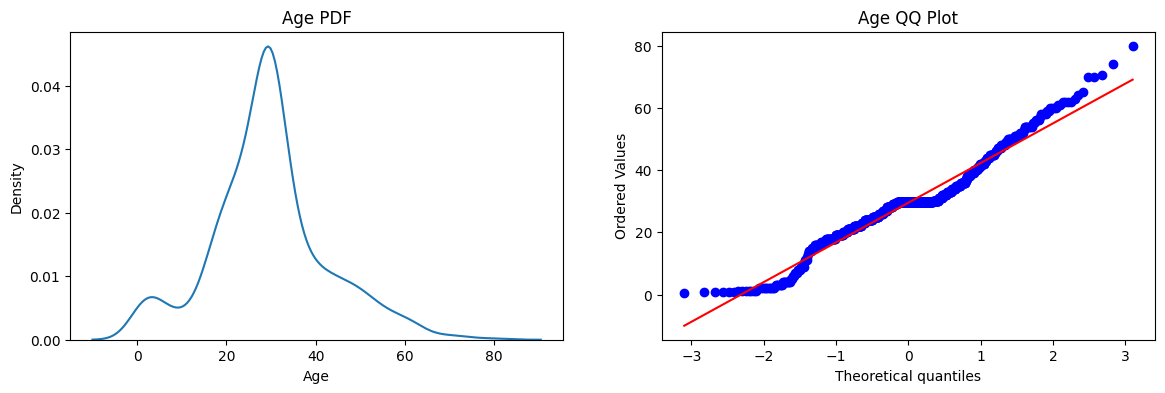

In [20]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
sns.kdeplot(X_train['Age'],ax=ax1)
ax1.set_title('Age PDF')

stats.probplot(X_train['Age'],dist='norm',plot=ax2)
ax2.set_title("Age QQ Plot")
plt.show()

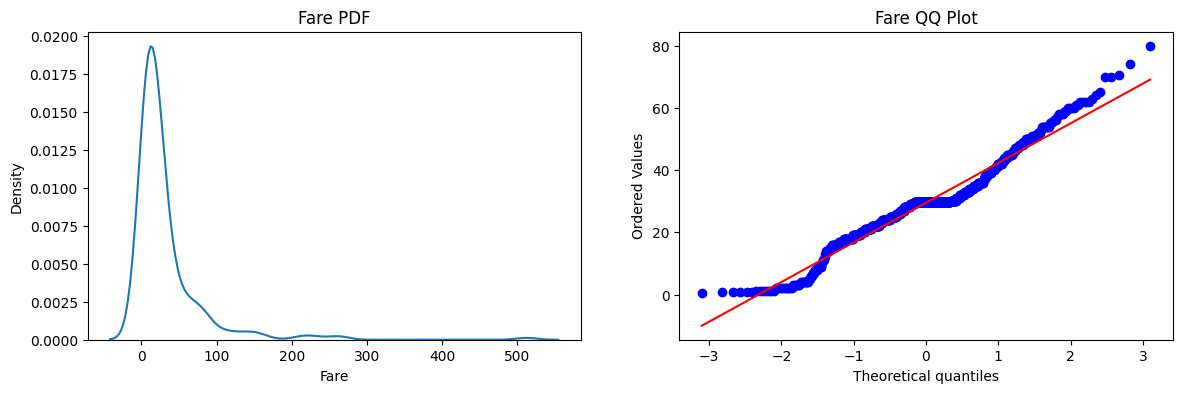

In [21]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
sns.kdeplot(X_train['Fare'],ax=ax1)
ax1.set_title('Fare PDF')

stats.probplot(X_train['Age'],dist='norm',plot=ax2)
ax2.set_title("Fare QQ Plot")
plt.show()

- for right skewed data you can use log transform

In [22]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [23]:
clf.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)

Y_pred=clf.predict(X_test)
Y_pred1=clf2.predict(X_test)

print("acc for lr",accuracy_score(Y_test,Y_pred))
print("acc for dt",accuracy_score(Y_test,Y_pred1))

acc for lr 0.6480446927374302
acc for dt 0.6815642458100558


In [24]:
trf=FunctionTransformer(func=np.log1p)

In [25]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [26]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(X_train_transformed,Y_train)
clf2.fit(X_train_transformed,Y_train)

Y_pred=clf.predict(X_test_transformed)
Y_pred1=clf2.predict(X_test_transformed)

print("acc for lr",accuracy_score(Y_test,Y_pred))
print("acc for dt",accuracy_score(Y_test,Y_pred1))

acc for lr 0.6815642458100558
acc for dt 0.6927374301675978


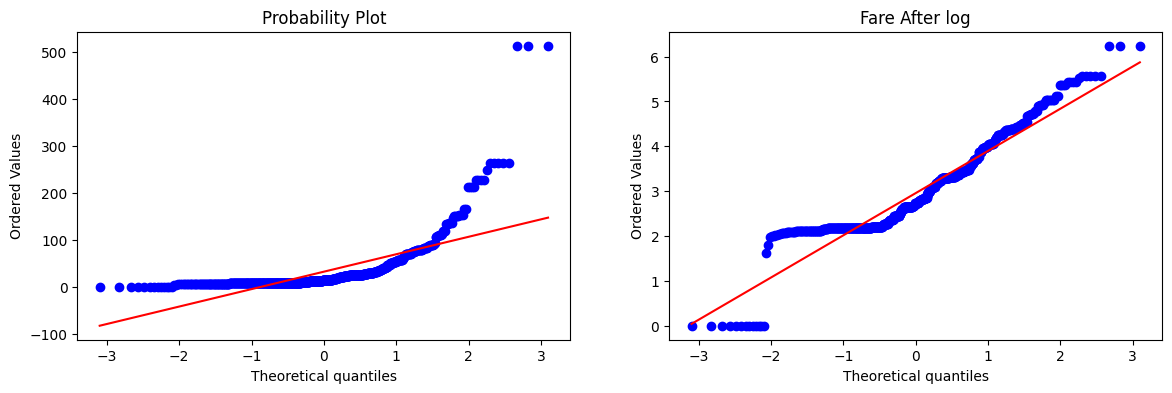

In [28]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
stats.probplot(X_train['Fare'],dist='norm',plot=ax1)
ax2.set_title("Fare Before log")

stats.probplot(X_train_transformed['Fare'],dist='norm',plot=ax2)
ax2.set_title("Fare After log")
plt.show()

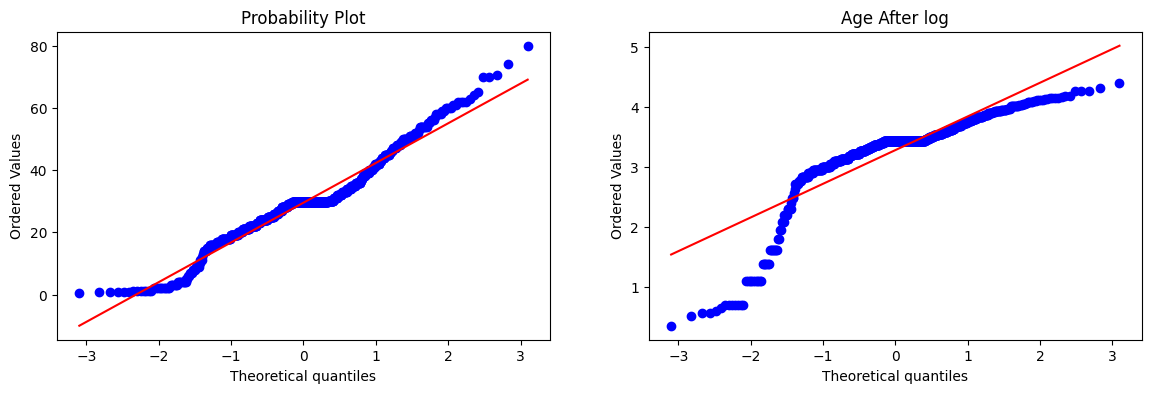

In [30]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
stats.probplot(X_train['Age'],dist='norm',plot=ax1)
ax2.set_title("Age Before log")

stats.probplot(X_train_transformed['Age'],dist='norm',plot=ax2)
ax2.set_title("Age After log")
plt.show()